# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Breast Cancer Wisconsin Dataset**.

**Deskripsi:**
- **Sumber:** Scikit-learn built-in datasets (awalnya dari UCI ML Repository)
- **Jumlah sampel:** 569 baris
- **Jumlah fitur:** 30 fitur numerik (hasil pengukuran sel tumor)
- **Target:** Diagnosis (0=Malignant/Ganas, 1=Benign/Jinak)
- **Task:** Klasifikasi biner

Dataset ini dipilih karena:
1. Belum digunakan dalam modul pembelajaran Dicoding
2. Memiliki fitur yang beragam dan cocok untuk demonstrasi pipeline ML
3. Relevan dengan dunia nyata (deteksi kanker)


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Semua library berhasil diimport!
Pandas  : 2.2.2
NumPy   : 2.0.2


# **3. Memuat Dataset**

In [2]:
# Load dataset
bc = load_breast_cancer()
df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
df['target'] = bc.target
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Fitur: {list(bc.feature_names)}')
df.head()

Dataset berhasil dimuat!
Shape: (569, 32)
Fitur: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
# Simpan raw dataset
os.makedirs('../breast_cancer_raw', exist_ok=True)
df.to_csv('../breast_cancer_raw/breast_cancer_raw.csv', index=False)
print('Raw dataset disimpan ke ../breast_cancer_raw/breast_cancer_raw.csv')

Raw dataset disimpan ke ../breast_cancer_raw/breast_cancer_raw.csv


# **4. Exploratory Data Analysis (EDA)**
Melakukan eksplorasi mendalam untuk memahami karakteristik dataset.

In [4]:
# 4.1 Informasi Dasar
print('='*55)
print('INFORMASI DASAR DATASET')
print('='*55)
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.info()

INFORMASI DASAR DATASET
Jumlah baris  : 569
Jumlah kolom  : 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error       

In [5]:
# 4.2 Statistik Deskriptif
print('STATISTIK DESKRIPTIF')
df.describe().round(3)

STATISTIK DESKRIPTIF


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


In [6]:
# 4.3 Missing Values
print('MISSING VALUES')
print(df.isnull().sum())
print(f'Total missing: {df.isnull().sum().sum()}')

MISSING VALUES
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64
Total missing: 0


In [7]:
# 4.4 Duplikasi
print(f'Jumlah duplikasi: {df.duplicated().sum()}')

Jumlah duplikasi: 0


DISTRIBUSI TARGET
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


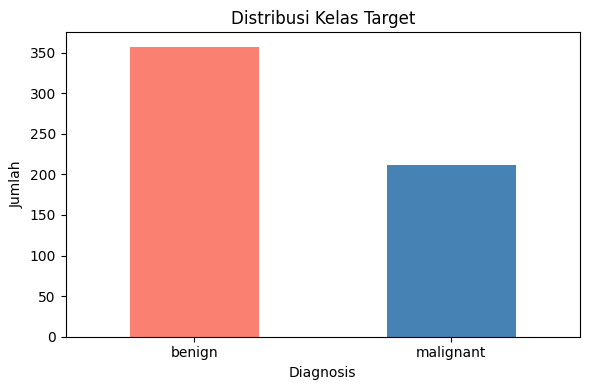

In [8]:
# 4.5 Distribusi Target
print('DISTRIBUSI TARGET')
print(df['diagnosis'].value_counts())

plt.figure(figsize=(6,4))
df['diagnosis'].value_counts().plot(kind='bar', color=['salmon','steelblue'])
plt.title('Distribusi Kelas Target')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

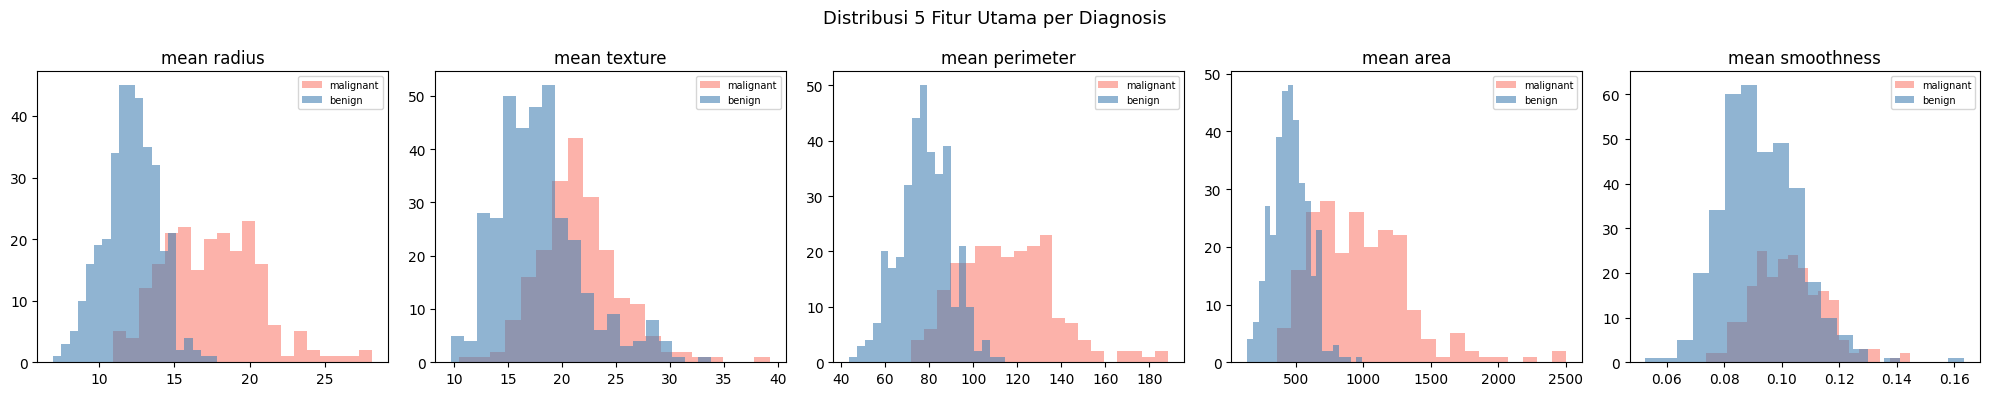

In [9]:
# 4.6 Distribusi 5 Fitur Utama
top_features = list(bc.feature_names[:5])
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(top_features):
    for diag, color in zip(['malignant','benign'], ['salmon','steelblue']):
        axes[i].hist(df[df['diagnosis']==diag][col], alpha=0.6,
                     label=diag, color=color, bins=20)
    axes[i].set_title(col[:15])
    axes[i].legend(fontsize=7)
plt.suptitle('Distribusi 5 Fitur Utama per Diagnosis', fontsize=13)
plt.tight_layout()
plt.show()

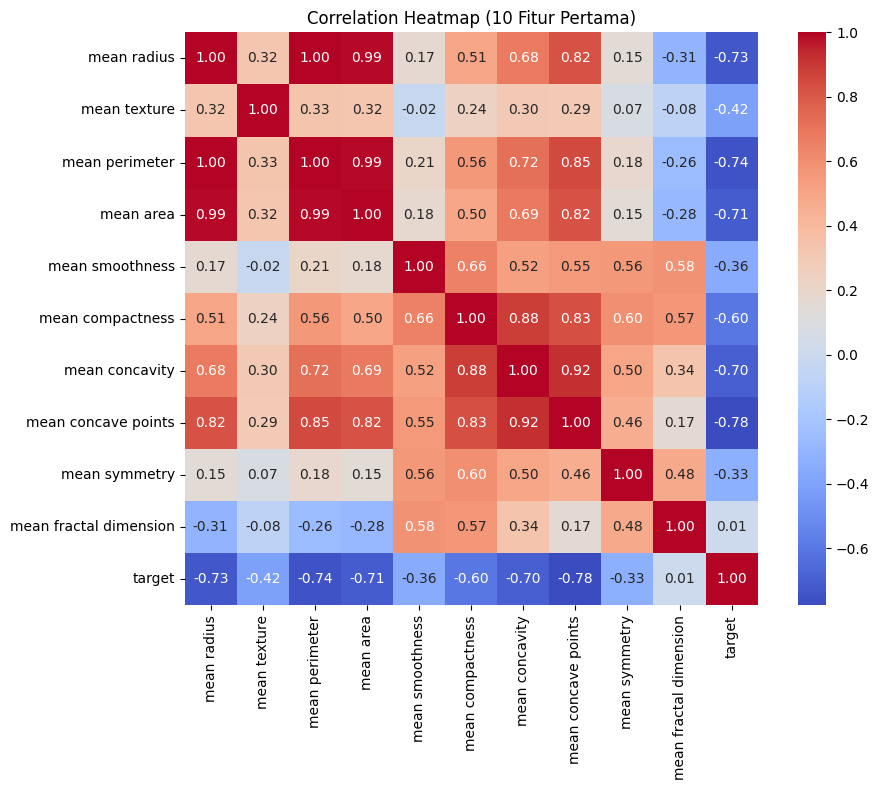

In [10]:
# 4.7 Correlation Heatmap (10 fitur pertama)
plt.figure(figsize=(10, 8))
corr_cols = list(bc.feature_names[:10]) + ['target']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (10 Fitur Pertama)')
plt.tight_layout()
plt.show()

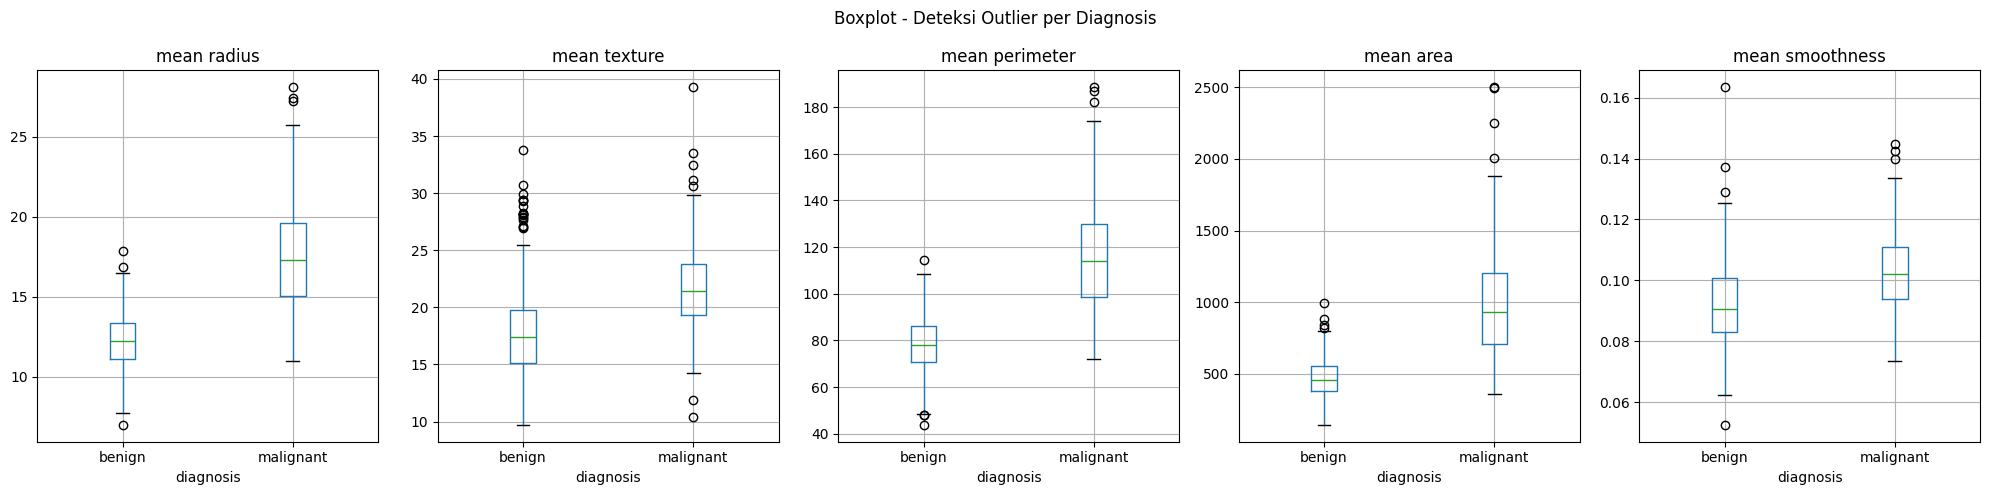

In [11]:
# 4.8 Boxplot Deteksi Outlier
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(top_features):
    df.boxplot(column=col, by='diagnosis', ax=axes[i])
    axes[i].set_title(col[:15])
plt.suptitle('Boxplot - Deteksi Outlier per Diagnosis')
plt.tight_layout()
plt.show()

**Ringkasan EDA:**
- Dataset memiliki **569 sampel** dengan **30 fitur numerik**
- Tidak ada missing values dan tidak ada duplikasi
- Distribusi kelas: 212 malignant (37.3%) dan 357 benign (62.7%) — sedikit imbalanced
- Fitur seperti `mean radius`, `mean perimeter` memiliki korelasi tinggi dengan target
- Terdapat outlier pada beberapa fitur, perlu ditangani
- Skala fitur berbeda-beda, perlu normalisasi

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Hapus duplikasi
2. Tangani missing values
3. Deteksi dan tangani outlier (IQR)
4. Normalisasi fitur (StandardScaler)
5. Split data (train/test)
6. Simpan dataset hasil preprocessing

In [12]:
# 5.1 Hapus Duplikasi
df_clean = df.copy()
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplikat dihapus: {before - len(df_clean)} baris')
print(f'Shape setelah: {df_clean.shape}')

Duplikat dihapus: 0 baris
Shape setelah: (569, 32)


In [13]:
# 5.2 Tangani Missing Values
feature_cols = list(bc.feature_names)
print('Missing values sebelum handling:')
print(df_clean[feature_cols].isnull().sum().sum())
for col in feature_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
print(f'Missing values setelah handling: {df_clean[feature_cols].isnull().sum().sum()}')

Missing values sebelum handling:
0
Missing values setelah handling: 0


In [14]:
# 5.3 Tangani Outlier (IQR)
def remove_outliers_iqr(df, columns):
    df_out = df.copy()
    total = 0
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_out)
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        removed = before - len(df_out)
        total += removed
        if removed > 0:
            print(f'{col}: {removed} outlier dihapus')
    print(f'Total outlier dihapus: {total}')
    print(f'Shape setelah: {df_out.shape}')
    return df_out

df_clean = remove_outliers_iqr(df_clean, feature_cols)

mean radius: 14 outlier dihapus
mean texture: 7 outlier dihapus
mean perimeter: 2 outlier dihapus
mean area: 33 outlier dihapus
mean smoothness: 6 outlier dihapus
mean compactness: 15 outlier dihapus
mean concavity: 13 outlier dihapus
mean concave points: 3 outlier dihapus
mean symmetry: 8 outlier dihapus
mean fractal dimension: 10 outlier dihapus
radius error: 23 outlier dihapus
texture error: 14 outlier dihapus
perimeter error: 10 outlier dihapus
area error: 23 outlier dihapus
smoothness error: 15 outlier dihapus
compactness error: 14 outlier dihapus
concavity error: 6 outlier dihapus
concave points error: 3 outlier dihapus
symmetry error: 15 outlier dihapus
fractal dimension error: 7 outlier dihapus
worst radius: 6 outlier dihapus
worst perimeter: 2 outlier dihapus
worst area: 11 outlier dihapus
worst smoothness: 3 outlier dihapus
worst compactness: 17 outlier dihapus
worst concavity: 5 outlier dihapus
worst concave points: 1 outlier dihapus
worst symmetry: 1 outlier dihapus
worst f

In [15]:
# 5.4 Normalisasi Fitur
X = df_clean[feature_cols].copy()
y = df_clean['target'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print('Statistik sebelum normalisasi:')
print(X.describe().round(3).iloc[:, :5])
print('\nStatistik setelah normalisasi:')
print(X_scaled_df.describe().round(3).iloc[:, :5])

Statistik sebelum normalisasi:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count      277.000       277.000         277.000    277.000          277.000
mean        12.658        17.856          81.258    501.578            0.091
std          1.665         3.830          11.128    130.468            0.011
min          8.196         9.710          51.710    201.900            0.063
25%         11.570        15.210          73.880    409.100            0.083
50%         12.760        17.460          81.370    496.600            0.090
75%         13.750        19.630          88.440    584.800            0.099
max         16.840        29.430         108.400    880.200            0.124

Statistik setelah normalisasi:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count      277.000       277.000         277.000    277.000          277.000
mean         0.000         0.000           0.000     -0.000           -0.000
std          

In [16]:
# 5.5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Total data  : {len(X_scaled_df)}')
print(f'Data train  : {len(X_train)} ({len(X_train)/len(X_scaled_df)*100:.1f}%)')
print(f'Data test   : {len(X_test)} ({len(X_test)/len(X_scaled_df)*100:.1f}%)')
print(f'\nDistribusi train:\n{y_train.value_counts()}')
print(f'\nDistribusi test:\n{y_test.value_counts()}')

Total data  : 277
Data train  : 221 (79.8%)
Data test   : 56 (20.2%)

Distribusi train:
target
1    203
0     18
Name: count, dtype: int64

Distribusi test:
target
1    52
0     4
Name: count, dtype: int64


In [17]:
# 5.6 Simpan Dataset Hasil Preprocessing
os.makedirs('../breast_cancer_preprocessing', exist_ok=True)

train_df = X_train.copy()
train_df['target'] = y_train.values
test_df = X_test.copy()
test_df['target'] = y_test.values

train_df.to_csv('../breast_cancer_preprocessing/breast_cancer_train.csv', index=False)
test_df.to_csv('../breast_cancer_preprocessing/breast_cancer_test.csv', index=False)

print('Dataset preprocessing berhasil disimpan!')
print(f'  - breast_cancer_train.csv : {train_df.shape}')
print(f'  - breast_cancer_test.csv  : {test_df.shape}')

Dataset preprocessing berhasil disimpan!
  - breast_cancer_train.csv : (221, 31)
  - breast_cancer_test.csv  : (56, 31)


**Ringkasan Preprocessing:**
- Tidak ada duplikasi yang dihapus
- Tidak ada missing values
- Outlier ditangani menggunakan metode IQR
- Fitur dinormalisasi menggunakan StandardScaler
- Data dibagi 80% training dan 20% testing dengan stratified split
- Dataset siap latih disimpan ke folder `breast_cancer_preprocessing/`

In [18]:
# Install library
!pip install mlflow==2.19.0 scikit-learn pandas numpy matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.0 MB/s eta 0:00:00


In [19]:
!python modelling.py

python3: can't open file '/content/modelling.py': [Errno 2] No such file or directory


In [20]:
!python /modelling.py

python3: can't open file '/modelling.py': [Errno 2] No such file or directory


In [21]:
import shutil, os

# Copy CSV ke /content/breast_cancer_preprocessing
os.makedirs('/content/breast_cancer_preprocessing', exist_ok=True)
shutil.copy('/breast_cancer_preprocessing/breast_cancer_train.csv', '/content/breast_cancer_preprocessing/breast_cancer_train.csv')
shutil.copy('/breast_cancer_preprocessing/breast_cancer_test.csv', '/content/breast_cancer_preprocessing/breast_cancer_test.csv')

print("✅ Semua file siap!")

# Jalankan modelling
os.chdir('/content')
!python modelling.py

✅ Semua file siap!
python3: can't open file '/content/modelling.py': [Errno 2] No such file or directory


In [22]:
import shutil

!python modelling_tuning.py

python3: can't open file '/content/modelling_tuning.py': [Errno 2] No such file or directory


In [23]:
!pip install dagshub -q
!python modelling_tuning.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.8 MB/s eta 0:00:00
python3: can't open file '/content/modelling_tuning.py': [Errno 2] No such file or directory


In [29]:
!zip -r mlruns.zip mlruns/
from google.colab import files
files.download('mlruns.zip')

updating: mlruns/ (stored 0%)
updating: mlruns/0/ (stored 0%)
updating: mlruns/0/meta.yaml (deflated 25%)
updating: mlruns/.trash/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import mlflow

client = mlflow.tracking.MlflowClient()
for exp_name in ['breast-cancer-classification', 'breast-cancer-tuning']:
    exp = client.get_experiment_by_name(exp_name)
    if exp:
        runs = client.search_runs(exp.experiment_id)
        print(f'\n{"="*55}')
        print(f'EXPERIMENT: {exp_name}')
        print(f'{"="*55}')
        for run in runs:
            print(f'Run: {run.info.run_name}')
            print(f'  Metrics: {run.data.metrics}')
            print(f'  Params : {run.data.params}')